# Exploratory Data Analysis — searching for a personalization opportunity

This notebook works **only** from the cleaned dataset `SBSA DS Case Study 2027 copy.csv`
(produced by `clean.ipynb`). No files are modified.

The six EDAs below follow one investigative thread: *is there a meaningful group of customers with a
shallow product relationship, who are nonetheless digitally reachable — and through which channel?*
Each EDA is followed by a plain-language markdown explaining what it shows and what it means.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('SBSA DS Case Study 2027 copy.csv')

products = ['Current_Account', 'Savings_Account', 'Credit_Card', 'Personal_Loan', 'Home_Loan', 'Vehicle_Loan']
channels = ['Online_Banking', 'Mobile_App', 'USSD']

# one fixed colour per entity, reused consistently across every chart
BLUE, GREEN, MAGENTA, YELLOW, AQUA, ORANGE = '#2a78d6', '#008300', '#e87ba4', '#eda100', '#1baf7a', '#eb6834'
GRAY, INK, SOFT = '#898781', '#0b0b0b', '#52514e'
PRODUCT_COLORS = dict(zip(products, [BLUE, GREEN, MAGENTA, YELLOW, AQUA, ORANGE]))
CHANNEL_COLORS = dict(zip(channels, [BLUE, GREEN, MAGENTA]))

plt.rcParams.update({
    'figure.facecolor': '#fcfcfb', 'axes.facecolor': '#fcfcfb',
    'axes.edgecolor': '#c3c2b7', 'axes.grid': True, 'grid.color': '#e1e0d9',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.axisbelow': True, 'font.size': 10,
})

def tidy(ax, pct=False):
    ax.grid(axis='x', visible=False)
    if pct:
        ax.set_ylim(0, 100)

print('Loaded cleaned dataset:', df.shape[0], 'customers,', df.shape[1], 'columns')

Loaded cleaned dataset: 9866 customers, 44 columns


**Setup.** Loads the cleaned data and fixes one colour per product and per channel, so the same thing
always looks the same across every chart in the notebook. Every percentage table printed alongside a chart
doubles as the exact numbers to quote in the presentation.

               Customers  Percentage
Products held                       
0                    576         5.8
1                   1870        19.0
2                   2816        28.5
3                   2535        25.7
4                   1531        15.5
5                    494         5.0
6                     44         0.4

Customers holding 0-2 products: 5262 (53.3% of the base)


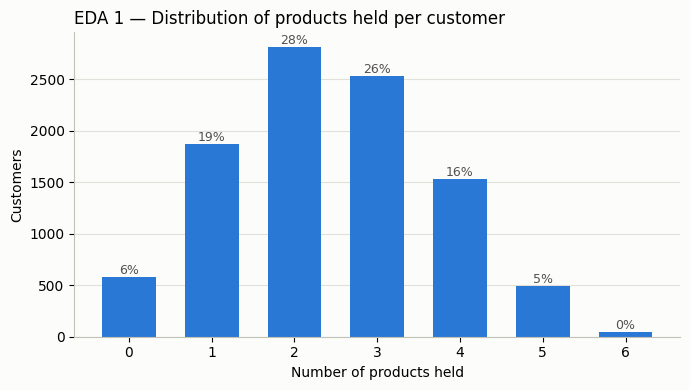

In [2]:
# ---- EDA 1: Distribution of number of products ----
counts = df['Num_Products'].value_counts().sort_index()
summary1 = pd.DataFrame({'Customers': counts,
                         'Percentage': (counts / len(df) * 100).round(1)})
summary1.index.name = 'Products held'
print(summary1)
low_share = (df['Num_Products'] <= 2).mean() * 100
print(f"\nCustomers holding 0-2 products: {(df['Num_Products'] <= 2).sum()} ({low_share:.1f}% of the base)")

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(summary1.index.astype(str), summary1['Customers'], color=BLUE, width=0.65)
for bar, pct in zip(bars, summary1['Percentage']):
    ax.annotate(f'{pct:.0f}%', (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='bottom', fontsize=9, color=SOFT)
ax.set_xlabel('Number of products held')
ax.set_ylabel('Customers')
ax.set_title('EDA 1 — Distribution of products held per customer', loc='left')
tidy(ax)
plt.tight_layout()
plt.show()

### EDA 1 — What this shows

Each bar is the number of customers holding that many of the bank's six products. The percentages on top
are the share of the whole (cleaned) customer base.

**The finding:** product holding is shallow. Over half the base — **53.3%** — holds **two products or
fewer**, including 19.0% with exactly one product and 5.8% with none at all. Only about 21% of customers
hold four or more.

**Why it matters:** a large low-product population is the precondition for a cross-selling /
personalization opportunity. If most customers already held 4–5 products there would be little room to
deepen relationships; instead, roughly every second customer has room to grow. The next EDAs zoom into who
these low-product customers are.

Single-product customers: 1870 (19.0% of the base)

                 Customers  % of single-product group  % of whole base
Only_Product                                                          
Personal_Loan          576                       30.8              5.8
Current_Account        511                       27.3              5.2
Savings_Account        347                       18.6              3.5
Credit_Card            235                       12.6              2.4
Vehicle_Loan           125                        6.7              1.3
Home_Loan               76                        4.1              0.8


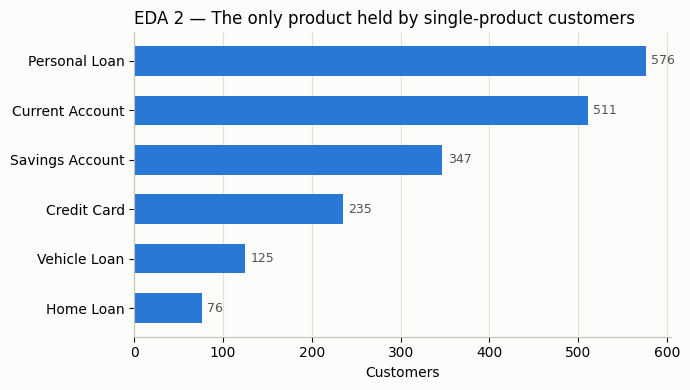

In [3]:
# ---- EDA 2: Products held by single-product customers ----
single = df[df['Num_Products'] == 1].copy()
single['Only_Product'] = single[products].idxmax(axis=1)

only_counts = single['Only_Product'].value_counts()
summary2 = pd.DataFrame({'Customers': only_counts,
                         '% of single-product group': (only_counts / len(single) * 100).round(1),
                         '% of whole base': (only_counts / len(df) * 100).round(1)})
print(f'Single-product customers: {len(single)} ({len(single) / len(df) * 100:.1f}% of the base)\n')
print(summary2)

fig, ax = plt.subplots(figsize=(7, 4))
labels = [p.replace('_', ' ') for p in only_counts.index]
bars = ax.barh(labels[::-1], only_counts.values[::-1], color=BLUE, height=0.6)
for bar in bars:
    ax.annotate(f'{int(bar.get_width())}', (bar.get_width(), bar.get_y() + bar.get_height() / 2),
                ha='left', va='center', fontsize=9, color=SOFT,
                xytext=(4, 0), textcoords='offset points')
ax.set_xlabel('Customers')
ax.set_title('EDA 2 — The only product held by single-product customers', loc='left')
ax.grid(axis='y', visible=False)
ax.grid(axis='x', color='#e1e0d9')
plt.tight_layout()
plt.show()

### EDA 2 — What this shows

Filtering to the 1,870 customers who hold **exactly one** product, this chart shows *which* product that
is.

**The finding:** the single biggest group is **personal-loan-only — 576 customers (30.8% of all
single-product customers, 5.8% of the entire base)**. It outranks current-account-only (511) and
savings-only (347); home-loan-only is the smallest (76).

**Why it matters:** a personal-loan-only customer is a striking relationship: the bank carries their credit
risk, yet holds none of their day-to-day banking — no transactional account, no savings. These customers
borrow here but bank elsewhere. That makes them the most natural cross-sell target in the base: the
relationship already exists, and the obvious next products (a transactional or savings account) are the
bank's cheapest to provide.

                 Customers  Median age  Average age  % aged 18-30  \
Only_Product                                                        
Personal_Loan          576        35.0         36.3          36.3   
Current_Account        511        36.0         37.0          33.5   
Savings_Account        347        38.0         38.1          24.5   
Credit_Card            235        34.0         34.4          42.1   
Vehicle_Loan           125        36.0         35.4          37.6   
Home_Loan               76        38.0         38.2          28.9   

                 % aged 18-35  
Only_Product                   
Personal_Loan            51.4  
Current_Account          49.3  
Savings_Account          43.5  
Credit_Card              54.0  
Vehicle_Loan             49.6  
Home_Loan                44.7  

Whole base, for comparison: median age 38  |  27.6% aged 18-30  |  42.0% aged 18-35


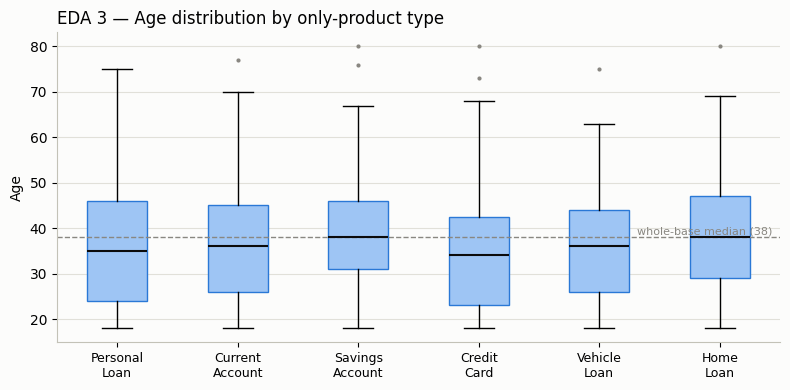

In [4]:
# ---- EDA 3: Age of each single-product group ----
order = single['Only_Product'].value_counts().index   # largest group first
g = single.groupby('Only_Product')['Age']
summary3 = pd.DataFrame({
    'Customers': g.count(),
    'Median age': g.median(),
    'Average age': g.mean().round(1),
    '% aged 18-30': g.apply(lambda s: (s <= 30).mean() * 100).round(1),
    '% aged 18-35': g.apply(lambda s: (s <= 35).mean() * 100).round(1),
}).loc[order]
print(summary3)
print(f"\nWhole base, for comparison: median age {df['Age'].median():.0f}  |  "
      f"{(df['Age'] <= 30).mean() * 100:.1f}% aged 18-30  |  {(df['Age'] <= 35).mean() * 100:.1f}% aged 18-35")

fig, ax = plt.subplots(figsize=(8, 4))
data = [single.loc[single['Only_Product'] == p, 'Age'] for p in order]
box = ax.boxplot(data, patch_artist=True,
                 medianprops=dict(color=INK, linewidth=1.5),
                 flierprops=dict(marker='o', markersize=3, markerfacecolor=GRAY, markeredgecolor='none'))
for patch in box['boxes']:
    patch.set(facecolor='#9ec5f4', edgecolor=BLUE)
ax.set_xticks(range(1, len(order) + 1))
ax.set_xticklabels([p.replace('_', '\n') for p in order], fontsize=9)
base_med = df['Age'].median()
ax.axhline(base_med, color=GRAY, linestyle='--', linewidth=1)
ax.annotate(f'whole-base median ({base_med:.0f})', xy=(0.99, base_med + 0.6),
            xycoords=('axes fraction', 'data'), ha='right', fontsize=8, color=GRAY)
ax.set_ylabel('Age')
ax.set_title('EDA 3 — Age distribution by only-product type', loc='left')
tidy(ax)
plt.tight_layout()
plt.show()

### EDA 3 — What this shows

For each "only-product" group: how many customers, their median and average age, and the share who are
young (18–30 and 18–35). The box plot shows each group's full age spread — the box is the middle 50% of
customers, the line inside it is the median — against the dashed line marking the whole base's median age
of 38.

**The finding:** every single-product group skews *younger* than the base, and the credit-led ones most of
all. Credit-card-only customers have a median age of 34 and personal-loan-only 35, versus 38 for the base.
**Over half (51.4%) of personal-loan-only customers are aged 18–35**, against 42.0% of the base overall.

**Why it matters:** the shallow-relationship, loan-led customers are disproportionately at the *start* of
their financial lives. That cuts two ways: they are the customers with the most lifetime value still ahead
of them, and they are the generation most comfortable being served — and sold to — through digital
channels, which EDA 5 tests directly.

Age_Band                  18-25    26-35    36-45    46-55   56-65     65+
Customers               1612.00  2536.00  2892.00  1936.00  727.00  163.00
Avg products               1.97     2.45     2.51     2.64    2.49    2.44
% exactly 1 product       27.50    18.80    16.70    15.60   18.30   17.80
% personal-loan-only       9.90     5.40     4.30     5.30    5.80    6.70
% hold Current Account    52.00    59.20    62.30    65.50   68.40   68.10
% hold Savings Account    34.20    55.60    57.80    62.10   52.50   59.50
% hold Credit Card        40.30    43.60    44.10    43.50   44.00   44.80
% hold Personal Loan      36.80    31.60    31.80    34.10   35.50   34.40
% hold Home Loan          12.50    24.40    25.20    28.70   19.00   17.80
% hold Vehicle Loan       21.60    30.20    30.20    29.90   29.20   19.60


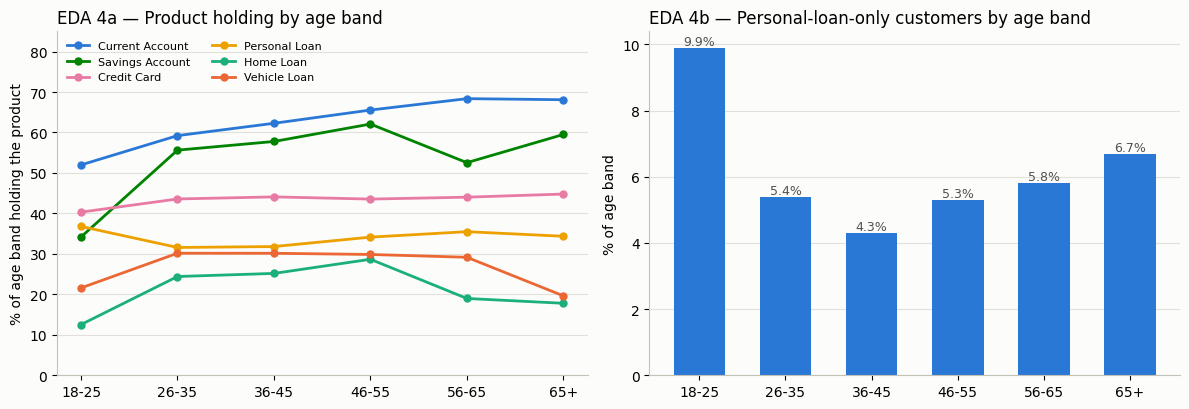

In [5]:
# ---- EDA 4: Product holding by age group ----
band_labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
df['Age_Band'] = pd.cut(df['Age'], bins=[17, 25, 35, 45, 55, 65, 100], labels=band_labels)
df['PL_Only'] = (df['Num_Products'] == 1) & df['Personal_Loan']

byband = df.groupby('Age_Band', observed=True)
summary4 = pd.DataFrame({
    'Customers': byband.size(),
    'Avg products': byband['Num_Products'].mean().round(2),
    '% exactly 1 product': (byband['Num_Products'].agg(lambda s: (s == 1).mean()) * 100).round(1),
    '% personal-loan-only': (byband['PL_Only'].mean() * 100).round(1),
})
for p in products:
    summary4['% hold ' + p.replace('_', ' ')] = (byband[p].mean() * 100).round(1)
print(summary4.T)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for p in products:
    axes[0].plot(band_labels, byband[p].mean() * 100, marker='o', markersize=5, linewidth=2,
                 color=PRODUCT_COLORS[p], label=p.replace('_', ' '))
axes[0].set_ylabel('% of age band holding the product')
axes[0].set_title('EDA 4a — Product holding by age band', loc='left')
axes[0].legend(fontsize=8, frameon=False, ncol=2, loc='upper left')
axes[0].set_ylim(0, 85)
tidy(axes[0])

bars = axes[1].bar(band_labels, summary4['% personal-loan-only'], color=BLUE, width=0.6)
for bar in bars:
    axes[1].annotate(f'{bar.get_height():.1f}%', (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     ha='center', va='bottom', fontsize=9, color=SOFT)
axes[1].set_ylabel('% of age band')
axes[1].set_title('EDA 4b — Personal-loan-only customers by age band', loc='left')
tidy(axes[1])
plt.tight_layout()
plt.show()

### EDA 4 — What this shows

The base is split into age bands from 18 upwards. The table gives, for every band: average number of
products, the share with exactly one product, the share holding each of the six products, and the share who
are personal-loan-only. Chart 4a traces how holding of each product changes with age; chart 4b isolates the
personal-loan-only share.

**The findings:**
- The **18–25 band has the shallowest relationships**: 1.97 products on average (vs ~2.5 for every older
  band) and **27.5% hold exactly one product** — one in four, versus roughly one in six elsewhere.
- **9.9% of all 18–25s are personal-loan-only** — about double the rate of every other age band (4–7%).
- Chart 4a shows why: anchor products *build with age*. Current-account holding climbs from 52% at 18–25 to
  ~68% at 56+, and savings from 34% to around 60%. Credit products don't show that build — personal-loan
  holding among 18–25s (36.8%) is already at the level of much older bands, and *exceeds* their savings
  holding (34.2%). The young borrow before they save.

**Why it matters:** this confirms the pattern EDA 3 hinted at — low product holding and reliance on
personal loans are **concentrated among younger customers**. The opportunity is to intercept these
customers early and deliberately build the anchor-product relationship that older cohorts acquired
gradually.

Low-product customers (1-2 products): 4686   |   comparison group (3+ products): 4604

                             1-2 products  3+ products
Online Banking registered %          51.6         70.8
Mobile App registered %              65.6         73.8
USSD registered %                    39.1         36.8
Any channel registered %             89.4         94.4
At least 1 digital txn %             83.2         90.0
Median digital txns                   5.0          8.0

Digital behaviour of 1-2 product customers, by age band:
          Customers  % any channel  % with txns  Median txns  \
Age_Band                                                       
18-25           926           90.0         83.6          5.0   
26-35          1195           89.9         84.0          5.0   
36-45          1330           89.5         83.4          5.0   
46-55           824           87.9         81.6          5.0   
56-65           325           90.8         82.8          5.0   
65+              86   

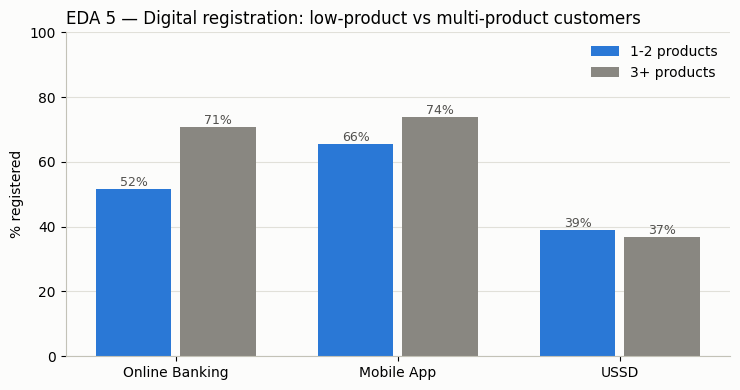

In [6]:
# ---- EDA 5: Digital behaviour of low-product customers ----
low = df[df['Num_Products'].isin([1, 2])]
multi = df[df['Num_Products'] >= 3]

def digital_profile(group):
    prof = {ch.replace('_', ' ') + ' registered %': group[ch + '_Registered'].mean() * 100 for ch in channels}
    prof['Any channel registered %'] = (group['Num_Digital_Channels'] > 0).mean() * 100
    prof['At least 1 digital txn %'] = (group['Total_Digital_Txns'] > 0).mean() * 100
    prof['Median digital txns'] = group['Total_Digital_Txns'].median()
    return pd.Series(prof).round(1)

summary5 = pd.DataFrame({'1-2 products': digital_profile(low), '3+ products': digital_profile(multi)})
print(f'Low-product customers (1-2 products): {len(low)}   |   comparison group (3+ products): {len(multi)}\n')
print(summary5)

lowband = low.groupby('Age_Band', observed=True)
tab_band = pd.DataFrame({
    'Customers': lowband.size(),
    '% any channel': (lowband['Num_Digital_Channels'].agg(lambda s: (s > 0).mean()) * 100).round(1),
    '% with txns': (lowband['Total_Digital_Txns'].agg(lambda s: (s > 0).mean()) * 100).round(1),
    'Median txns': lowband['Total_Digital_Txns'].median()})
for ch in channels:
    tab_band['% ' + ch.replace('_', ' ')] = (lowband[ch + '_Registered'].mean() * 100).round(1)
print('\nDigital behaviour of 1-2 product customers, by age band:')
print(tab_band)

sgrp = single.groupby('Only_Product')
tab_only = pd.DataFrame({
    'Customers': sgrp.size(),
    '% with txns': (sgrp['Total_Digital_Txns'].agg(lambda s: (s > 0).mean()) * 100).round(1),
    'Median txns': sgrp['Total_Digital_Txns'].median()})
for ch in channels:
    tab_only['% ' + ch.replace('_', ' ')] = (sgrp[ch + '_Registered'].mean() * 100).round(1)
print('\nDigital behaviour by only-product type (single-product customers):')
print(tab_only.loc[order])

fig, ax = plt.subplots(figsize=(7.5, 4))
x = np.arange(len(channels))
reg_low = [low[ch + '_Registered'].mean() * 100 for ch in channels]
reg_multi = [multi[ch + '_Registered'].mean() * 100 for ch in channels]
b1 = ax.bar(x - 0.19, reg_low, width=0.34, color=BLUE, label='1-2 products')
b2 = ax.bar(x + 0.19, reg_multi, width=0.34, color=GRAY, label='3+ products')
for bars in (b1, b2):
    for bar in bars:
        ax.annotate(f'{bar.get_height():.0f}%', (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    ha='center', va='bottom', fontsize=9, color=SOFT)
ax.set_xticks(x)
ax.set_xticklabels([c.replace('_', ' ') for c in channels])
ax.set_ylabel('% registered')
ax.set_title('EDA 5 — Digital registration: low-product vs multi-product customers', loc='left')
ax.legend(frameon=False)
tidy(ax, pct=True)
plt.tight_layout()
plt.show()

### EDA 5 — What this shows

This is the decisive test. If the low-product customers (1–2 products, **4,686 people — 47.5% of the
base**) were digitally disconnected, reaching them would first require a costly adoption campaign. The
tables profile their digital registration and *actual* transacting, overall, by age band, and by
only-product type; the chart compares their channel registration against multi-product customers.

**The findings:**
- Low-product customers are **digitally reachable already**: 89.4% are registered on at least one digital
  channel, **83.2% have made at least one digital transaction**, with a median of 5 transactions. That is
  only modestly behind multi-product customers (94.4%, 90.0%, median 8) — and only 6.2% are digitally
  dormant.
- This holds **across every age band** (87.9–90.8% registered on any channel) — it is not just a
  young-customer effect.
- By product type: **personal-loan-only customers are the least likely to use online banking (33.9%) but
  the *most* likely to be registered for USSD (47.2%)** — a first hint that this segment leans on the
  most basic channel, which EDA 6 pursues.

**Why it matters:** the low-product group is *not* a digital-adoption problem — it is a
**cross-selling opportunity**. The rails to reach them personally, cheaply and at scale already exist;
what is missing is the product relationship, not the connection.

               Customers  % of base  % with txns  Median total txns  \
Location_Type                                                         
Township            5221       52.9         84.4                5.0   
Suburban            2110       21.4         85.0                5.0   
Urban               2535       25.7         89.3               10.0   

               % reg Online Banking  % reg Mobile App  % reg USSD  
Location_Type                                                      
Township                       53.6              65.8        48.0  
Suburban                       63.8              69.7        33.0  
Urban                          68.8              74.9        21.6  

Share of transaction volume done on each channel, within each location type (%):
               Online Banking  Mobile App  USSD
Location_Type                                  
Township                 23.4        42.0  34.6
Suburban                 34.5        53.0  12.6
Urban                    36.5 

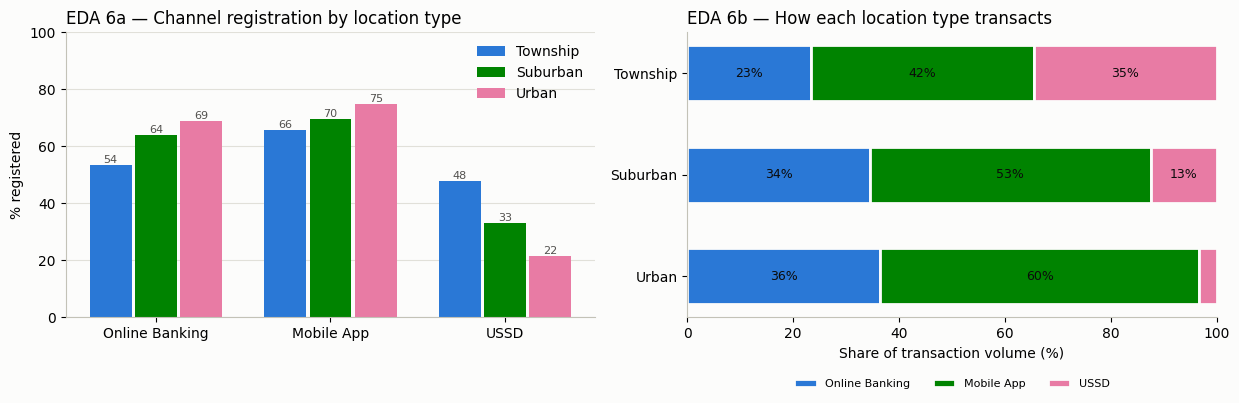

In [7]:
# ---- EDA 6: Location type and technology utilisation ----
loc_order = ['Township', 'Suburban', 'Urban']
LOC_COLORS = dict(zip(loc_order, [BLUE, GREEN, MAGENTA]))
txn_cols = [ch + '_Txns' for ch in channels]
bylocation = df.groupby('Location_Type')

summary6 = pd.DataFrame({
    'Customers': bylocation.size(),
    '% of base': (bylocation.size() / len(df) * 100).round(1),
    '% with txns': (bylocation['Total_Digital_Txns'].agg(lambda s: (s > 0).mean()) * 100).round(1),
    'Median total txns': bylocation['Total_Digital_Txns'].median()})
for ch in channels:
    summary6['% reg ' + ch.replace('_', ' ')] = (bylocation[ch + '_Registered'].mean() * 100).round(1)
print(summary6.loc[loc_order])

share = df.groupby('Location_Type')[txn_cols].sum()
share = (share.div(share.sum(axis=1), axis=0) * 100).round(1).loc[loc_order]
share.columns = [c.replace('_Txns', '').replace('_', ' ') for c in share.columns]
print('\nShare of transaction volume done on each channel, within each location type (%):')
print(share)

df['Township_Flag'] = np.where(df['Location_Type'] == 'Township', 'Township', 'Non-township')
tw = df.groupby('Township_Flag')
tab_tw = pd.DataFrame({
    'Customers': tw.size(),
    '% with txns': (tw['Total_Digital_Txns'].agg(lambda s: (s > 0).mean()) * 100).round(1),
    'Median txns': tw['Total_Digital_Txns'].median()})
for ch in channels:
    tab_tw['% reg ' + ch.replace('_', ' ')] = (tw[ch + '_Registered'].mean() * 100).round(1)
print('\nTownship vs non-township:')
print(tab_tw)

low_township = df[(df['Location_Type'] == 'Township') & df['Num_Products'].isin([1, 2])]
mix = low_township[txn_cols].sum()
mix = (mix / mix.sum() * 100).round(1)
print(f'\nChannel mix of LOW-PRODUCT township customers (n={len(low_township)}) — share of their transactions:')
print(mix.rename(lambda c: c.replace('_Txns', '').replace('_', ' ')).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
x = np.arange(len(channels))
for i, lt in enumerate(loc_order):
    vals = [df.loc[df['Location_Type'] == lt, ch + '_Registered'].mean() * 100 for ch in channels]
    bars = axes[0].bar(x + (i - 1) * 0.26, vals, width=0.24, color=LOC_COLORS[lt], label=lt)
    for bar in bars:
        axes[0].annotate(f'{bar.get_height():.0f}', (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                         ha='center', va='bottom', fontsize=8, color=SOFT)
axes[0].set_xticks(x)
axes[0].set_xticklabels([c.replace('_', ' ') for c in channels])
axes[0].set_ylabel('% registered')
axes[0].set_title('EDA 6a — Channel registration by location type', loc='left')
axes[0].legend(frameon=False)
tidy(axes[0], pct=True)

y = np.arange(len(loc_order))
left = np.zeros(len(loc_order))
for ch in channels:
    vals = share[ch.replace('_', ' ')].values
    axes[1].barh(y, vals, left=left, height=0.55, color=CHANNEL_COLORS[ch],
                 edgecolor='#fcfcfb', linewidth=2, label=ch.replace('_', ' '))
    for yi, (v, l) in enumerate(zip(vals, left)):
        if v > 7:
            axes[1].text(l + v / 2, yi, f'{v:.0f}%', ha='center', va='center', fontsize=9, color=INK)
    left += vals
axes[1].set_yticks(y)
axes[1].set_yticklabels(loc_order)
axes[1].invert_yaxis()
axes[1].set_xlim(0, 100)
axes[1].set_xlabel('Share of transaction volume (%)')
axes[1].set_title('EDA 6b — How each location type transacts', loc='left')
axes[1].legend(frameon=False, fontsize=8, ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.18))
axes[1].grid(visible=False)
plt.tight_layout()
plt.show()

### EDA 6 — What this shows

The base is split by location type — **Township (5,221 customers, 52.9% of the base)**, Urban (2,535) and
Suburban (2,110) — and their technology use is compared: which channels they are registered for (chart 6a)
and, more tellingly, which channels their transactions *actually happen on* (chart 6b, each bar summing to
100% of that location type's transaction volume).

**The findings:**
- Township customers are digitally engaged (84.4% have transacted digitally — barely behind the 87.4% of
  non-township customers) but they engage through **different technology**.
- **USSD registration: 48% in townships vs 33% suburban and just 22% urban.** Conventional online banking
  shows the reverse gradient (54% township vs 69% urban).
- The transaction mix makes it vivid: **more than a third (34.6%) of all township transaction volume runs
  over USSD — ten times the urban share (3.3%)**. Urban customers transact almost entirely on the app and
  online banking.
- Township vs non-township in one line: similar activity levels (median 5 vs 7 transactions), completely
  different channel mix.
- Crucially, this survives the intersection with our target group: for **low-product township customers
  (n = 2,711 — over half of the entire low-product segment), USSD carries 38.7% of their transactions**,
  essentially level with the mobile app (40.2%).

**Why it matters:** any personalization / cross-sell solution delivered only through the app or online
banking would structurally exclude much of the township half of the customer base — the very customers
over-represented in the low-product target group. **The solution must be delivered on USSD as well as the
app**, or it will miss the people it is most meant for.

## Where the six EDAs point

Read in sequence, the EDAs build one coherent business case:

1. **The market exists** — 53.3% of customers hold ≤ 2 products (EDA 1).
2. **It has a face** — the largest single-product group is **personal-loan-only** (576 customers): people
   whose credit the bank carries but whose day-to-day banking happens elsewhere (EDA 2).
3. **It's young** — single-product and loan-led customers skew 18–35 (EDA 3), and the 18–25 band has both
   the fewest products (1.97 avg) and double the personal-loan-only rate of any other band; the young
   borrow before they save (EDA 4).
4. **It's reachable** — 89% of low-product customers are digitally registered and 83% actively transact,
   so this is a **cross-selling opportunity, not a digital-adoption problem** (EDA 5).
5. **But it must be inclusive** — townships are 53% of the base and run a third of their digital activity
   over **USSD**; low-product township customers use USSD nearly as much as the app (EDA 6).

**The opportunity in one sentence:** a personalized, digitally-delivered cross-sell programme aimed at
young, low-product (especially personal-loan-only) customers — offering the natural next products
(transactional and savings accounts) through the channels they already use, **including USSD**, so the
township majority of the target group is served rather than excluded.